# RexVal Correlation Analysis

Replicates Table 1 format from CRIMSON (arXiv 2603.06183):  
**Kendall τ and Pearson r** between automatic metrics and radiologist clinically significant error counts.

**Table structure**: each column = one RexVal candidate type (n=50 studies per column).  
**ICARE variants**: ICARE_GT (questions from GT), ICARE_GEN (questions from Gen), ICARE_AVG (mean of both — primary metric).

Also includes **radiologist preference analysis**: does ICARE pick the same best candidate as radiologists?

In [29]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# ── Paths ─────────────────────────────────────────────────────────────────────
BASE      = '/gpfs/data/oermannlab/users/rd3571/ICARE_score'
DATA_BASE = '/gpfs/data/oermannlab/users/rd3571/cxr_report_datasets'
EVAL_DIR  = f'{BASE}/outputs/rexval/rexval_test_200/eval_seed_123/shuffled_ans_choices_data'

REPORT_CSV = f'{DATA_BASE}/rexval/RexVal_test_icare_200.csv'
LABELS_CSV = (f'{DATA_BASE}/rexval_physionet_labels/physionet.org'
              '/files/rexval-dataset/1.0.0/6_valid_raters_per_rater_error_categories.csv')

GT_STATS  = f'{EVAL_DIR}/gt_reports_as_ref/mcqa_eval/mcq_eval_report_level_stats.csv'
GEN_STATS = f'{EVAL_DIR}/gen_reports_as_ref/mcqa_eval/mcq_eval_report_level_stats.csv'

OUT_DIR = f'{BASE}/outputs/rexval/rexval_test_200'

# RexVal candidate types = column groups in the paper's Table 1
CANDIDATES = ['radgraph', 'bertscore', 's_emb', 'bleu']

## 1. Load data

In [30]:
# Report metadata: Report_ID (row index 0-199) → study_number + origin (= candidate_type)
reports = pd.read_csv(REPORT_CSV)
reports.insert(0, 'Report_ID', range(len(reports)))
reports = reports[['Report_ID', 'study_number', 'origin']]
print(f'Reports: {len(reports)} rows | {reports["study_number"].nunique()} studies | candidates: {sorted(reports["origin"].unique())}')

Reports: 200 rows | 50 studies | candidates: ['bertscore', 'bleu', 'radgraph', 's_emb']


In [31]:
# ICARE report-level scores (shuffled_ans_choices_data, both references)
gt_scores  = pd.read_csv(GT_STATS).rename(columns={'Agreement_Percentage': 'ICARE_GT'})
gen_scores = pd.read_csv(GEN_STATS).rename(columns={'Agreement_Percentage': 'ICARE_GEN'})

icare = gt_scores.merge(gen_scores, on='Report_ID')
icare['ICARE_AVG'] = (icare['ICARE_GT'] + icare['ICARE_GEN']) / 2

# Disagreement = 100 - agreement.
# Higher disagreement → worse report → more errors.
# Using disagreement for correlation makes the sign match CRIMSON Table 1
# (positive τ/r = metric correctly detects worse reports).
icare['ICARE_DIS_GT']  = 100 - icare['ICARE_GT']
icare['ICARE_DIS_GEN'] = 100 - icare['ICARE_GEN']
icare['ICARE_DIS_AVG'] = 100 - icare['ICARE_AVG']

icare = icare.merge(reports, on='Report_ID')
print(icare[['Report_ID', 'study_number', 'origin',
             'ICARE_GT', 'ICARE_GEN', 'ICARE_AVG',
             'ICARE_DIS_GT', 'ICARE_DIS_GEN', 'ICARE_DIS_AVG']].head(8).to_string(index=False))

 Report_ID  study_number    origin  ICARE_GT  ICARE_GEN  ICARE_AVG  ICARE_DIS_GT  ICARE_DIS_GEN  ICARE_DIS_AVG
         0             0  radgraph 26.315789 100.000000  63.157895     73.684211       0.000000      36.842105
         1             0 bertscore 26.666667  36.363636  31.515152     73.333333      63.636364      68.484848
         2             0     s_emb 35.714286  76.923077  56.318681     64.285714      23.076923      43.681319
         3             0      bleu 30.769231  61.538462  46.153846     69.230769      38.461538      53.846154
         4             1  radgraph 13.333333 100.000000  56.666667     86.666667       0.000000      43.333333
         5             1 bertscore 26.666667  60.000000  43.333333     73.333333      40.000000      56.666667
         6             1     s_emb 43.750000  72.727273  58.238636     56.250000      27.272727      41.761364
         7             1      bleu 33.333333  62.500000  47.916667     66.666667      37.500000      52.083333


In [32]:
# Radiologist labels
labels = pd.read_csv(LABELS_CSV)
print(f'Labels shape: {labels.shape}')
print(f'Columns: {labels.columns.tolist()}')
print(f'Candidate types in labels: {sorted(labels["candidate_type"].unique())}')
labels.head(4)

Labels shape: (14400, 6)
Columns: ['study_number', 'candidate_type', 'error_category', 'rater_index', 'clinically_significant', 'num_errors']
Candidate types in labels: ['bertscore', 'bleu', 'radgraph', 's_emb']


,study_number,candidate_type,error_category,rater_index,clinically_significant,num_errors
0,0,radgraph,1,0,True,0
1,0,radgraph,1,1,True,0
2,0,radgraph,1,2,True,0
3,0,radgraph,1,3,True,0


## 2. Compute per-report radiologist error score

Filter to `clinically_significant=True`, sum errors per rater per (study, candidate), then average across the 6 raters.

In [33]:
clin_sig = labels[labels['clinically_significant'] == True].copy()

# Sum across all error categories per (study, candidate, rater)
per_rater = (clin_sig
             .groupby(['study_number', 'candidate_type', 'rater_index'], as_index=False)['num_errors']
             .sum()
             .rename(columns={'num_errors': 'errors_this_rater'}))

# Average across 6 raters per (study, candidate)
error_scores = (per_rater
                .groupby(['study_number', 'candidate_type'], as_index=False)['errors_this_rater']
                .mean()
                .rename(columns={'candidate_type': 'origin',
                                 'errors_this_rater': 'mean_clin_sig_errors'}))

print(f'Error scores: {len(error_scores)} (study, candidate) pairs')
error_scores.head(8)

Error scores: 200 (study, candidate) pairs


,study_number,origin,mean_clin_sig_errors
0,0,bertscore,1.666667
1,0,bleu,1.666667
2,0,radgraph,0.833333
3,0,s_emb,1.833333
4,1,bertscore,1.166667
5,1,bleu,1.500000
6,1,radgraph,2.166667
7,1,s_emb,1.833333


In [34]:
# Merge ICARE + error scores on (study_number, origin)
merged = icare.merge(error_scores, on=['study_number', 'origin'])
print(f'Merged: {len(merged)} pairs ({merged["study_number"].nunique()} studies × {merged["origin"].nunique()} candidates)')
merged[['study_number', 'origin', 'ICARE_GT', 'ICARE_GEN', 'ICARE_AVG', 'mean_clin_sig_errors']].head(8)

Merged: 200 pairs (50 studies × 4 candidates)


,study_number,origin,ICARE_GT,ICARE_GEN,ICARE_AVG,mean_clin_sig_errors
0,0,radgraph,26.315789,100.000000,63.157895,0.833333
1,0,bertscore,26.666667,36.363636,31.515152,1.666667
2,0,s_emb,35.714286,76.923077,56.318681,1.833333
3,0,bleu,30.769231,61.538462,46.153846,1.666667
4,1,radgraph,13.333333,100.000000,56.666667,2.166667
5,1,bertscore,26.666667,60.000000,43.333333,1.166667
6,1,s_emb,43.750000,72.727273,58.238636,1.833333
7,1,bleu,33.333333,62.500000,47.916667,1.500000


## 3. Correlation analysis

Matching CRIMSON Table 1: **one column per candidate type** (n=50 studies each).  
For each cell: correlate [ICARE score for that candidate] vs [radiologist error count for that candidate] across 50 studies.  
95% CI via bootstrapping (1000 iterations).

In [35]:
def bootstrap_ci(x, y, stat_fn, n_boot=1000, ci=95, seed=42):
    rng = np.random.default_rng(seed)
    n = len(x)
    samples = []
    for _ in range(n_boot):
        idx = rng.integers(0, n, n)
        samples.append(stat_fn(x[idx], y[idx]))
    lo = np.percentile(samples, (100 - ci) / 2)
    hi = np.percentile(samples, 100 - (100 - ci) / 2)
    return lo, hi


def compute_corr_table(df, score_col):
    """Compute Kendall τ and Pearson r for each candidate type column."""
    results = {}
    for cand in CANDIDATES:
        sub = df[df['origin'] == cand].copy()
        x = sub[score_col].values          # disagreement score (higher = worse)
        y = sub['mean_clin_sig_errors'].values  # radiologist errors (higher = worse)

        tau, tau_p = stats.kendalltau(x, y)
        r,   r_p   = stats.pearsonr(x, y)

        tau_lo, tau_hi = bootstrap_ci(x, y, lambda a, b: stats.kendalltau(a, b)[0])
        r_lo,   r_hi   = bootstrap_ci(x, y, lambda a, b: stats.pearsonr(a, b)[0])

        results[cand] = dict(tau=tau, tau_p=tau_p, tau_lo=tau_lo, tau_hi=tau_hi,
                              r=r,   r_p=r_p,   r_lo=r_lo,   r_hi=r_hi)
    return results


# Correlate using disagreement scores so sign matches CRIMSON Table 1
corr = {col: compute_corr_table(merged, col)
        for col in ['ICARE_DIS_GT', 'ICARE_DIS_GEN', 'ICARE_DIS_AVG']}
print('Done.')

Done.


## 4. Formatted table — same layout as CRIMSON Table 1

In [36]:
def fmt(val, lo, hi):
    return f'{val:.2f} [{lo:.2f}, {hi:.2f}]'

# Display labels: strip the DIS_ prefix for readability
LABEL = {'ICARE_DIS_GT': 'ICARE_GT', 'ICARE_DIS_GEN': 'ICARE_GEN', 'ICARE_DIS_AVG': 'ICARE_AVG ◄'}

rows = []
for dis_col, label in LABEL.items():
    row = {'Metric': label}
    for cand in CANDIDATES:
        c = corr[dis_col][cand]
        row[f'{cand}\nKendall τ'] = fmt(c['tau'], c['tau_lo'], c['tau_hi'])
        row[f'{cand}\nPearson r'] = fmt(c['r'],   c['r_lo'],   c['r_hi'])
    rows.append(row)

table = pd.DataFrame(rows).set_index('Metric')
print('Kendall τ and Pearson r (95% CI) | n=50 per column')
print('Scores = ICARE disagreement (100 - agreement); positive = detects worse reports\n')
table

Kendall τ and Pearson r (95% CI) | n=50 per column
Scores = ICARE disagreement (100 - agreement); positive = detects worse reports



,radgraph\nKendall τ,radgraph\nPearson r,bertscore\nKendall τ,bertscore\nPearson r,s_emb\nKendall τ,s_emb\nPearson r,bleu\nKendall τ,bleu\nPearson r
Metric,,,,,,,,
ICARE_GT,"0.59 [0.41, 0.73]","0.66 [0.45, 0.82]","0.57 [0.40, 0.71]","0.61 [0.44, 0.77]","0.59 [0.43, 0.72]","0.70 [0.52, 0.83]","0.64 [0.50, 0.76]","0.74 [0.61, 0.86]"
ICARE_GEN,"0.50 [0.33, 0.63]","0.61 [0.43, 0.78]","0.59 [0.48, 0.71]","0.66 [0.55, 0.79]","0.61 [0.46, 0.73]","0.71 [0.56, 0.83]","0.51 [0.32, 0.66]","0.61 [0.45, 0.75]"
ICARE_AVG ◄,"0.67 [0.54, 0.77]","0.77 [0.64, 0.87]","0.61 [0.48, 0.71]","0.71 [0.63, 0.80]","0.66 [0.51, 0.78]","0.78 [0.66, 0.87]","0.62 [0.47, 0.75]","0.75 [0.62, 0.85]"


## 5. Scatter plots: ICARE_AVG vs error counts (one panel per candidate)

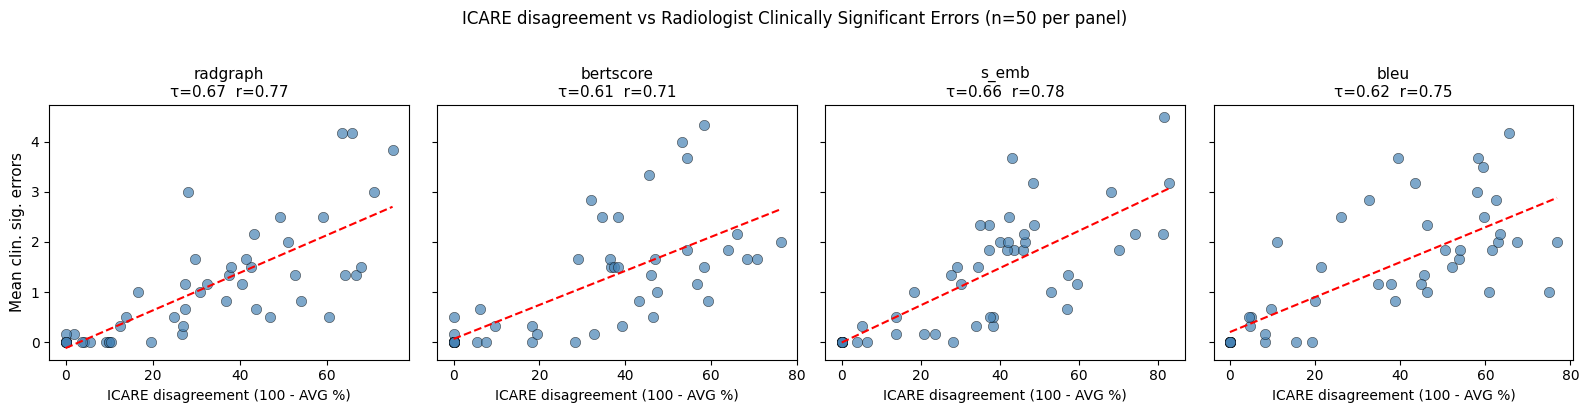

In [38]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=True)

for ax, cand in zip(axes, CANDIDATES):
    sub = merged[merged['origin'] == cand]
    c = corr['ICARE_DIS_AVG'][cand]
    ax.scatter(sub['ICARE_DIS_AVG'], sub['mean_clin_sig_errors'],
               alpha=0.7, edgecolors='k', linewidths=0.4, s=55, color='steelblue')
    m, b = np.polyfit(sub['ICARE_DIS_AVG'], sub['mean_clin_sig_errors'], 1)
    xs = np.linspace(sub['ICARE_DIS_AVG'].min(), sub['ICARE_DIS_AVG'].max(), 100)
    ax.plot(xs, m * xs + b, 'r--', linewidth=1.5)
    ax.set_xlabel('ICARE disagreement (100 - AVG %)', fontsize=10)
    ax.set_title(f'{cand}\nτ={c["tau"]:.2f}  r={c["r"]:.2f}', fontsize=11)

axes[0].set_ylabel('Mean clin. sig. errors', fontsize=11)
plt.suptitle('ICARE disagreement vs Radiologist Clinically Significant Errors (n=50 per panel)', y=1.02)
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/icare_vs_errors_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Radiologist preference analysis

For each of the 50 studies, the 4 candidates are ranked by:
- **Radiologist preference**: lowest mean clinically significant errors = rank 1 (best)
- **ICARE preference**: highest ICARE_AVG = rank 1 (best)

We then ask: do they agree on the **top-1 candidate**? And how correlated are the full rankings?

In [ ]:
# Rank candidates within each study
# Radiologist: lowest errors = rank 1 (best)
# ICARE: lowest disagreement (= highest agreement) = rank 1 (best)
merged['rad_rank']   = merged.groupby('study_number')['mean_clin_sig_errors'].rank(ascending=True, method='min')
merged['icare_rank'] = merged.groupby('study_number')['ICARE_DIS_AVG'       ].rank(ascending=True, method='min')

# Top-1 winner per study
rad_top1   = (merged[merged['rad_rank']   == 1][['study_number', 'origin']]
              .drop_duplicates('study_number').rename(columns={'origin': 'rad_winner'}))
icare_top1 = (merged[merged['icare_rank'] == 1][['study_number', 'origin']]
              .drop_duplicates('study_number').rename(columns={'origin': 'icare_winner'}))

pref = rad_top1.merge(icare_top1, on='study_number')
pref['agree'] = pref['rad_winner'] == pref['icare_winner']

agree_pct = pref['agree'].mean() * 100
print(f'Top-1 candidate agreement: {pref["agree"].sum()}/{len(pref)} studies ({agree_pct:.1f}%)')
print()
print('Agreement rate when radiologist picked each candidate:')
print(pref.groupby('rad_winner')['agree'].agg(agreed='sum', total='count', rate='mean').to_string())

Top-1 candidate agreement: 19/50 studies (38.0%)

Agreement rate when radiologist picked each candidate:
            agreed  total      rate
rad_winner                         
bertscore        5     16  0.312500
bleu             0      2  0.000000
radgraph        12     26  0.461538
s_emb            2      6  0.333333


In [12]:
# Per-study Spearman rank correlation (ICARE ranking vs radiologist ranking across 4 candidates)
spearman_per_study = (
    merged.groupby('study_number')
    .apply(lambda g: stats.spearmanr(g['icare_rank'], g['rad_rank'])[0])
    .reset_index(name='spearman_r')
)

print('Per-study Spearman r (ICARE ranking vs radiologist ranking):')
print(f"  Mean      : {spearman_per_study['spearman_r'].mean():.3f}")
print(f"  Median    : {spearman_per_study['spearman_r'].median():.3f}")
print(f"  Std       : {spearman_per_study['spearman_r'].std():.3f}")
print(f"  % positive: {(spearman_per_study['spearman_r'] > 0).mean()*100:.1f}%")

Per-study Spearman r (ICARE ranking vs radiologist ranking):
  Mean      : 0.356
  Median    : 0.500
  Std       : 0.604
  % positive: 60.0%


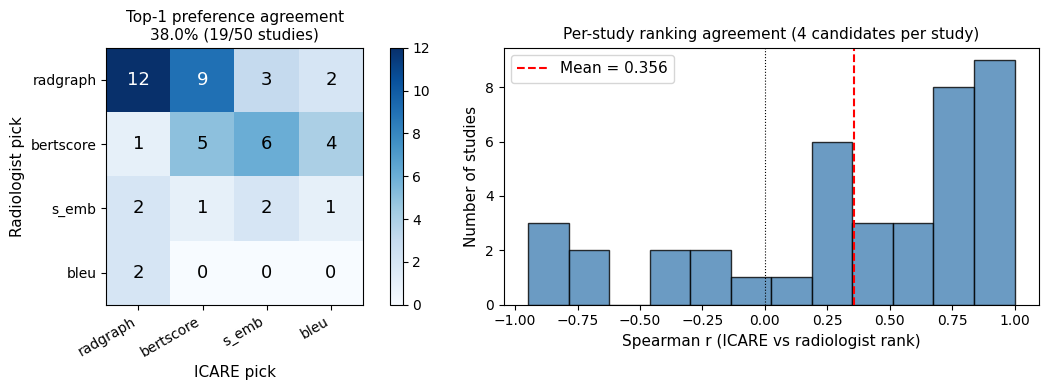

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: confusion matrix of radiologist winner vs ICARE winner
conf = pd.crosstab(pref['rad_winner'], pref['icare_winner'],
                   rownames=['Radiologist pick'], colnames=['ICARE pick'])
conf = conf.reindex(index=CANDIDATES, columns=CANDIDATES, fill_value=0)
im = axes[0].imshow(conf.values, cmap='Blues')
axes[0].set_xticks(range(len(CANDIDATES))); axes[0].set_xticklabels(CANDIDATES, rotation=30, ha='right')
axes[0].set_yticks(range(len(CANDIDATES))); axes[0].set_yticklabels(CANDIDATES)
axes[0].set_xlabel('ICARE pick', fontsize=11)
axes[0].set_ylabel('Radiologist pick', fontsize=11)
axes[0].set_title(f'Top-1 preference agreement\n{agree_pct:.1f}% ({pref["agree"].sum()}/{len(pref)} studies)', fontsize=11)
for i in range(len(CANDIDATES)):
    for j in range(len(CANDIDATES)):
        axes[0].text(j, i, conf.values[i, j], ha='center', va='center', fontsize=13,
                     color='white' if conf.values[i, j] > conf.values.max() * 0.6 else 'black')
plt.colorbar(im, ax=axes[0])

# Right: distribution of per-study Spearman r
axes[1].hist(spearman_per_study['spearman_r'], bins=12, edgecolor='k', color='steelblue', alpha=0.8)
axes[1].axvline(spearman_per_study['spearman_r'].mean(), color='r', linestyle='--',
                label=f"Mean = {spearman_per_study['spearman_r'].mean():.3f}")
axes[1].axvline(0, color='k', linewidth=0.8, linestyle=':')
axes[1].set_xlabel('Spearman r (ICARE vs radiologist rank)', fontsize=11)
axes[1].set_ylabel('Number of studies', fontsize=11)
axes[1].set_title('Per-study ranking agreement (4 candidates per study)', fontsize=11)
axes[1].legend(fontsize=11)

plt.tight_layout()
plt.savefig(f'{OUT_DIR}/preference_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Summary

In [14]:
sep = '=' * 75
print(sep)
print('ICARE: Kendall τ and Pearson r with radiologist clinically significant errors')
print('n=50 per column | columns = RexVal candidate types')
print(sep)
print(f'{"Metric":12s}', end='')
for cand in CANDIDATES:
    print(f'  {cand:^35s}', end='')
print()
print(f'{"":12s}', end='')
for _ in CANDIDATES:
    print(f'  {"Kendall τ [95%CI]":^17s}{"Pearson r [95%CI]":^18s}', end='')
print()
print('-' * 75)
for dis_col, label in LABEL.items():
    marker = ' ◄' if dis_col == 'ICARE_DIS_AVG' else ''
    line = f'{label + marker:14s}'
    for cand in CANDIDATES:
        c = corr[dis_col][cand]
        line += f'  {fmt(c["tau"],c["tau_lo"],c["tau_hi"]):^17s}{fmt(c["r"],c["r_lo"],c["r_hi"]):^18s}'
    print(line)

print()
print(sep)
print('Radiologist preference analysis (ICARE_AVG)')
print(sep)
print(f'Top-1 candidate agreement : {agree_pct:.1f}%  ({pref["agree"].sum()}/{len(pref)} studies)')
print(f'Mean per-study Spearman r  : {spearman_per_study["spearman_r"].mean():.3f}  '
      f'(SD {spearman_per_study["spearman_r"].std():.3f})')
print(f'% studies with positive r  : {(spearman_per_study["spearman_r"] > 0).mean()*100:.1f}%')
print(sep)

ICARE: Kendall τ and Pearson r with radiologist clinically significant errors
n=50 per column | columns = RexVal candidate types
Metric                     radgraph                             bertscore                              s_emb                                bleu                
              Kendall τ [95%CI]Pearson r [95%CI]   Kendall τ [95%CI]Pearson r [95%CI]   Kendall τ [95%CI]Pearson r [95%CI]   Kendall τ [95%CI]Pearson r [95%CI] 
---------------------------------------------------------------------------
ICARE_GT        0.59 [0.41, 0.73]0.66 [0.45, 0.82]   0.57 [0.40, 0.71]0.61 [0.44, 0.77]   0.59 [0.43, 0.72]0.70 [0.52, 0.83]   0.64 [0.50, 0.76]0.74 [0.61, 0.86] 
ICARE_GEN       0.50 [0.33, 0.63]0.61 [0.43, 0.78]   0.59 [0.48, 0.71]0.66 [0.55, 0.79]   0.61 [0.46, 0.73]0.71 [0.56, 0.83]   0.51 [0.32, 0.66]0.61 [0.45, 0.75] 
ICARE_AVG ◄ ◄   0.67 [0.54, 0.77]0.77 [0.64, 0.87]   0.61 [0.48, 0.71]0.71 [0.63, 0.80]   0.66 [0.51, 0.78]0.78 [0.66, 0.87]   0.62 [0.47, 0.75]0.7

## 8. Baseline metric correlations (BLEU, BERTScore, s-emb, RadGraph, RadCliQ)

Run `scripts/rexval_data/rrg_eval_baselines_rexval.sh` first to generate per-report metric scores.  
Results land at: `outputs/rexval/rexval_test_200/baselines/`

Quality metrics (higher = better) are negated → `1 - metric` so positive τ/r = correctly detects worse reports.

In [ ]:
BASELINES_DIR = f'{BASE}/outputs/rexval/rexval_test_200/baselines'

baseline_raw = pd.read_csv(f'{BASELINES_DIR}/rexval_test_200/rexval_prepared_results.csv')
print(f'Baseline results shape: {baseline_raw.shape}')
print(f'Columns: {baseline_raw.columns.tolist()}')
baseline_raw.head(4)

In [ ]:
import json as _json

# Rename study_id → Report_ID to match ICARE/error data
baseline_raw = baseline_raw.rename(columns={'study_id': 'Report_ID'})
baseline_raw['Report_ID'] = baseline_raw['Report_ID'].astype(int)

# Load CRIMSON scores
with open(f'{BASELINES_DIR}/crimson_results.json') as _f:
    crimson_json = _json.load(_f)
crimson_df = pd.DataFrame({
    'Report_ID': range(200),
    'crimson_score': [r['crimson_score'] for r in crimson_json['results']]
})

# Load GREEN scores
green_raw = pd.read_csv(f'{BASELINES_DIR}/green/rexval_prepared_green_results.csv')
green_df = green_raw[['index', 'green_score']].rename(columns={'index': 'Report_ID'})

merged_all = (
    merged
    .merge(baseline_raw[['Report_ID', 'bleu_score', 'bertscore', 'semb_score',
                          'radgraph_combined', 'RadCliQ-v1']],
           on='Report_ID', how='inner')
    .merge(crimson_df, on='Report_ID', how='inner')
    .merge(green_df,   on='Report_ID', how='inner')
)
print(f'Merged with baselines: {len(merged_all)} rows')

# Disagreement convention: higher = more errors (positive correlation with error counts)
# Quality metrics (higher=better): negate
for m in ['bleu_score', 'bertscore', 'semb_score', 'radgraph_combined',
          'crimson_score', 'green_score']:
    merged_all[f'neg_{m}'] = -merged_all[m]   # same ordering as 1-m for corr

# RadCliQ-v1: already higher=worse (error metric), use raw — do NOT negate

BASELINE_COLS = {
    'BLEU':       'neg_bleu_score',
    'BERTScore':  'neg_bertscore',
    's-emb':      'neg_semb_score',
    'RadGraph':   'neg_radgraph_combined',
    'RadCliQ-v1': 'RadCliQ-v1',      # raw: higher = more errors = worse
    'GREEN':      'neg_green_score',
    'CRIMSON':    'neg_crimson_score',
}
merged_all[list(BASELINE_COLS.values())].describe()

## 9. Predefined question ICARE

Runs a fixed bank of 45 questions (not per-report generated) across all 200 RexVal reports.  
Predefined results: `outputs/rexval/predefined/eval_seed_123/mcqa_eval/`

This section answers: **is dynamic ICARE better than a fixed question bank?**  
Both variants appear in the same table below for direct comparison.

In [17]:
PREDEFINED_EVAL = f'{BASE}/outputs/rexval/predefined/eval_seed_123/mcqa_eval/mcqa_eval_answer_predictions.csv'

pred_df = pd.read_csv(PREDEFINED_EVAL)
print(f'Predefined eval: {len(pred_df)} rows | '
      f'{pred_df["Report_ID"].nunique()} reports × {pred_df["Question_ID"].nunique()} questions')

# Per-report agreement: % of questions where GT and Gen predictions agree
pred_agree = (
    pred_df
    .groupby('Report_ID')
    .apply(lambda g: (g['Predicted_Answer_Using_GT'] == g['Predicted_Answer_Using_Gen']).mean() * 100)
    .reset_index(name='ICARE_PREDEFINED')
)
pred_agree['ICARE_DIS_PREDEFINED'] = 100 - pred_agree['ICARE_PREDEFINED']

# Add predefined disagreement scores to merged_all
merged_all = merged_all.merge(pred_agree[['Report_ID', 'ICARE_DIS_PREDEFINED']], on='Report_ID', how='inner')
print(f'After predefined merge: {len(merged_all)} rows')
print(pred_agree['ICARE_DIS_PREDEFINED'].describe())

Predefined eval: 9000 rows | 200 reports × 45 questions
After predefined merge: 200 rows
count    200.000000
mean      21.766667
std       13.982516
min        0.000000
25%       11.111111
50%       22.222222
75%       33.333333
max       55.555556
Name: ICARE_DIS_PREDEFINED, dtype: float64


In [ ]:
# ── Compute correlations ──
baseline_corr = {label: compute_corr_table(merged_all, col)
                 for label, col in BASELINE_COLS.items()}
pred_corr = compute_corr_table(merged_all, 'ICARE_DIS_PREDEFINED')

# ── Ordered rows: baselines first, ICARE at bottom ──
CAND_DISPLAY = {'radgraph': 'RadGraph', 'bertscore': 'BERTScore',
                's_emb': 'SembScore', 'bleu': 'BLEU'}

# LaTeX names (for paper)
METRIC_LATEX = {
    'ICARE_GT':         r'ICARE$_{\text{GT}}$',
    'ICARE_GEN':        r'ICARE$_{\text{GEN}}$',
    'ICARE_AVG ◄':      r'\textbf{ICARE$_{\text{AVG}}$}',
    'ICARE_PREDEFINED': r'ICARE$_{\text{PRE}}$',
    'BLEU':             'BLEU',
    'BERTScore':        'BERTScore',
    's-emb':            'SembScore',
    'RadGraph':         'RadGraph',
    'RadCliQ-v1':       'RadCliQ-v1',
    'GREEN':            'GREEN',
    'CRIMSON':         'CRIMSON',
}
# Plain names (for matplotlib)
METRIC_PLT = {
    'ICARE_GT':         'ICARE (GT)',
    'ICARE_GEN':        'ICARE (GEN)',
    'ICARE_AVG ◄':      'ICARE (AVG)',
    'ICARE_PREDEFINED': 'ICARE (PRE)',
    'BLEU':             'BLEU',
    'BERTScore':        'BERTScore',
    's-emb':            'SembScore',
    'RadGraph':         'RadGraph',
    'RadCliQ-v1':       'RadCliQ-v1',
    'GREEN':            'GREEN',
    'CRIMSON':         'CRIMSON',
}

def row_values(cand_results):
    return {c: (cand_results[c]['tau'], cand_results[c]['tau_lo'], cand_results[c]['tau_hi'],
                cand_results[c]['r'],   cand_results[c]['r_lo'],   cand_results[c]['r_hi'])
            for c in CANDIDATES}

ordered_rows = []
for lbl, col_results in baseline_corr.items():
    ordered_rows.append((lbl, 'baseline', row_values(col_results)))
for dis_col, lbl in LABEL.items():
    ordered_rows.append((lbl, 'icare', row_values(corr[dis_col])))
ordered_rows.append(('ICARE_PREDEFINED', 'icare', row_values(pred_corr)))

CAND_SPLITS = [CANDIDATES[:2], CANDIDATES[2:]]

def fmtv(v, lo, hi):
    return f'{v:.2f} [{lo:.2f},{hi:.2f}]'

best_tau = {c: max(r[2][c][0] for r in ordered_rows) for c in CANDIDATES}
best_r   = {c: max(r[2][c][3] for r in ordered_rows) for c in CANDIDATES}

# ═══════════════════════════════════════════════════════════════════
# 1.  LaTeX table (booktabs style, two sub-tables)
# ═══════════════════════════════════════════════════════════════════
def make_latex_subtable(cands):
    n = len(cands)
    lines = [r'\begin{tabular}{l' + 'rr'*n + r'}', r'\toprule']

    h1 = [''] + [r'\multicolumn{2}{c}{\textbf{' + CAND_DISPLAY[c] + '}}' for c in cands]
    lines.append(' & '.join(h1) + r' \\')
    clines = [r'\cmidrule(lr){' + f'{2+ci*2}-{3+ci*2}' + '}' for ci in range(n)]
    lines.append('  '.join(clines))

    h2 = ['Metric'] + [r'Kendall $\tau$', r'Pearson $r$'] * n
    lines += [' & '.join(h2) + r' \\', r'\midrule']

    prev_sec = None
    for lbl, sec, vals in ordered_rows:
        if sec != prev_sec and prev_sec is not None:
            lines.append(r'\midrule')
        name = METRIC_LATEX.get(lbl, lbl.replace('_', r'\_'))
        cells = [name]
        for c in cands:
            tau, tlo, thi, r, rlo, rhi = vals[c]
            ts = fmtv(tau, tlo, thi)
            rs = fmtv(r,   rlo, rhi)
            if abs(tau - best_tau[c]) < 1e-9:
                ts = r'\textbf{' + ts + '}'
            if abs(r - best_r[c]) < 1e-9:
                rs = r'\textbf{' + rs + '}'
            cells += [ts, rs]
        lines.append(' & '.join(cells) + r' \\')
        prev_sec = sec

    lines += [r'\bottomrule', r'\end{tabular}']
    return '\n'.join(lines)

full_latex = (
    r'\begin{table}[t]' + '\n'
    r'\centering' + '\n'
    r'\small' + '\n'
    r'\caption{Correlation with radiologist clinically significant error counts '
    r'($n{=}50$ per column). Bold = best in column. '
    r'ICARE variants shown at bottom.}' + '\n'
    r'\label{tab:correlation}' + '\n' +
    make_latex_subtable(CAND_SPLITS[0]) + '\n\n' +
    r'\vspace{4pt}' + '\n' +
    make_latex_subtable(CAND_SPLITS[1]) + '\n' +
    r'\end{table}'
)
print('=' * 72)
print('LATEX TABLE — copy into your paper:')
print('=' * 72)
print(full_latex)
print('=' * 72)

# ═══════════════════════════════════════════════════════════════════
# 2.  Compact matplotlib PNG
# ═══════════════════════════════════════════════════════════════════
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

plt.rcParams.update({'font.size': 10, 'font.family': 'DejaVu Sans'})

def draw_subtable(ax, cands, y_top, row_h=0.30, fs_h=9.5, fs_d=9.0):
    n = len(cands)
    col_w = [0.21] + [0.125, 0.145]*n
    xe = list(np.cumsum([0] + col_w))

    HDR='#1B2631'; WH='white'; BASE='white'; ALT='#F0F3F4'; ICARE='#D6EAF8'

    def cell(x, y, w, h, t, bg, fg='#1C2833', bold=False, fs=9.5, ha='c', btop=False):
        ax.add_patch(mpatches.FancyBboxPatch(
            (x, y-h/2), w, h, boxstyle='square,pad=0',
            facecolor=bg, edgecolor='none', lw=0, zorder=1))
        tx = x + w/2 if ha=='c' else x + 0.006
        ax.text(tx, y, t, ha='center' if ha=='c' else 'left',
                va='center', fontsize=fs, color=fg,
                fontweight='bold' if bold else 'normal', zorder=2, clip_on=False)
        if btop:
            ax.plot([x, x+w], [y+h/2]*2, color='#AAB7B8', lw=0.7, zorder=3)

    # hdr 1
    cell(xe[0], y_top, col_w[0], row_h, 'Metric', HDR, WH, bold=True, fs=fs_h)
    for ci, c in enumerate(cands):
        ws = col_w[1+ci*2]+col_w[2+ci*2]
        cell(xe[1+ci*2], y_top, ws, row_h, CAND_DISPLAY[c], HDR, WH, bold=True, fs=fs_h)
        ax.plot([xe[2+ci*2]]*2, [y_top-row_h/2, y_top+row_h/2],
                color='#566573', lw=0.5, zorder=4)
    # hdr 2
    y2 = y_top - row_h
    cell(xe[0], y2, col_w[0], row_h, '', HDR, WH)
    for ci in range(n):
        cell(xe[1+ci*2], y2, col_w[1+ci*2], row_h, 'Kendall τ', HDR, WH, fs=fs_h)
        cell(xe[2+ci*2], y2, col_w[2+ci*2], row_h, 'Pearson r',  HDR, WH, fs=fs_h)

    # data
    prev_sec = None
    y_last = y2
    for ri, (lbl, sec, vals) in enumerate(ordered_rows):
        yr = y2 - row_h*(ri+1); y_last = yr
        btop = (sec != prev_sec and prev_sec is not None)
        bg = ICARE if sec=='icare' else (ALT if ri%2 else BASE)
        fg = '#1A5276' if sec=='icare' else '#1C2833'
        name = METRIC_PLT.get(lbl, lbl)
        cell(xe[0], yr, col_w[0], row_h, name, bg, fg,
             bold=(sec=='icare'), fs=fs_d, ha='l', btop=btop)
        for ci, c in enumerate(cands):
            tau, tlo, thi, r, rlo, rhi = vals[c]
            tb = abs(tau-best_tau[c])<1e-9
            rb = abs(r  -best_r[c])<1e-9
            cell(xe[1+ci*2], yr, col_w[1+ci*2], row_h,
                 fmtv(tau,tlo,thi), bg, fg, bold=(tb or sec=='icare'), fs=fs_d, btop=btop)
            cell(xe[2+ci*2], yr, col_w[2+ci*2], row_h,
                 fmtv(r,rlo,rhi),   bg, fg, bold=(rb or sec=='icare'), fs=fs_d, btop=btop)
        prev_sec = sec

    # borders
    tw = xe[-1]
    for lx in [xe[0], tw]:
        ax.plot([lx]*2, [y_last-row_h/2, y_top+row_h/2], color='#1B2631', lw=1.0, zorder=5)
    ax.plot([xe[0],tw], [y_top+row_h/2]*2,  color='#1B2631', lw=1.5, zorder=5)
    ax.plot([xe[0],tw], [y_last-row_h/2]*2, color='#1B2631', lw=1.5, zorder=5)
    return y_last - row_h/2

N = len(ordered_rows); row_h = 0.30
sub_h = (N+2)*row_h; gap = 0.38
fig_h = sub_h*2 + gap + 0.45

col_w_sample = [0.21]+[0.125,0.145]*2; total_w = sum(col_w_sample)
fig_w = total_w * 24

fig, ax = plt.subplots(figsize=(fig_w, fig_h))
ax.set_xlim(0, total_w); ax.set_ylim(0, fig_h); ax.axis('off')

y1 = fig_h - 0.25
bot1 = draw_subtable(ax, CAND_SPLITS[0], y_top=y1, row_h=row_h)
draw_subtable(ax, CAND_SPLITS[1], y_top=bot1-gap, row_h=row_h)

fig.suptitle(
    'Correlation with Radiologist Clinically Significant Error Counts  (n = 50 per column)\n'
    'Blue = ICARE variants  |  Bold = best in column',
    fontsize=10.5, y=0.995)
plt.savefig(f'{OUT_DIR}/correlation_table.png', dpi=200, bbox_inches='tight')
plt.show()
print('Saved correlation_table.png')


## 10. Radiologist preference alignment — all metrics + inter-rater agreement

For each metric we ask: **does it pick the same best candidate as radiologists?**  
We also compute **inter-rater agreement** as a natural ceiling — the maximum agreement any metric could achieve if radiologists themselves disagreed.

- **Top-1 alignment**: % of studies where metric's top-ranked candidate = radiologist's top-ranked candidate (lowest mean errors)  
- **Random baseline**: 25% (4 candidates, random pick)  
- **Inter-rater ceiling**: pairwise top-1 agreement between the 6 individual raters  
- **Inter-rater Spearman r**: mean pairwise Spearman r on full 4-candidate rankings per study

In [19]:
from itertools import combinations

# Per-rater error counts per (study, candidate)
rater_errors = (
    clin_sig
    .groupby(['study_number', 'candidate_type', 'rater_index'])['num_errors']
    .sum()
    .reset_index()
    .rename(columns={'candidate_type': 'origin'})
)

# Rank candidates per rater per study (lowest errors = rank 1 = best)
rater_errors['rater_rank'] = (
    rater_errors
    .groupby(['study_number', 'rater_index'])['num_errors']
    .rank(ascending=True, method='min')
)

# ── Pairwise Spearman r on full 4-candidate rankings ──
raters = sorted(rater_errors['rater_index'].unique())
pairs_r = []
for study in rater_errors['study_number'].unique():
    sd = rater_errors[rater_errors['study_number'] == study]
    for r1, r2 in combinations(raters, 2):
        d1 = sd[sd['rater_index'] == r1].set_index('origin')['rater_rank']
        d2 = sd[sd['rater_index'] == r2].set_index('origin')['rater_rank']
        common = d1.index.intersection(d2.index)
        if len(common) >= 2:
            rho, _ = stats.spearmanr(d1[common], d2[common])
            pairs_r.append(rho)

inter_rater_spearman = np.mean(pairs_r)

# ── Pairwise top-1 agreement ──
rater_top1 = (
    rater_errors[rater_errors['rater_rank'] == 1]
    .groupby(['study_number', 'rater_index'])['origin']
    .first()
    .reset_index()
)
pair_top1_agree = []
for study in rater_top1['study_number'].unique():
    top1s = rater_top1[rater_top1['study_number'] == study].set_index('rater_index')['origin']
    for r1, r2 in combinations(top1s.index, 2):
        pair_top1_agree.append(top1s[r1] == top1s[r2])

inter_rater_top1 = np.mean(pair_top1_agree) * 100

print(f'Inter-rater mean pairwise Spearman r : {inter_rater_spearman:.3f}  '
      f'(n={len(pairs_r)} study-pair observations)')
print(f'Inter-rater pairwise top-1 agreement : {inter_rater_top1:.1f}%  '
      f'(n={len(pair_top1_agree)} rater-pairs × studies)')

Inter-rater mean pairwise Spearman r : nan  (n=750 study-pair observations)
Inter-rater pairwise top-1 agreement : 68.1%  (n=750 rater-pairs × studies)


In [ ]:
# Radiologist top-1 per study (lowest mean_clin_sig_errors = best)
merged_all['_rad_rank'] = (
    merged_all.groupby('study_number')['mean_clin_sig_errors']
    .rank(ascending=True, method='min')
)
rad_top1_all = (
    merged_all[merged_all['_rad_rank'] == 1][['study_number', 'origin']]
    .drop_duplicates('study_number')
    .rename(columns={'origin': 'rad_winner'})
)

# Metrics to evaluate: (display_label, column_in_merged_all, ascending)
# ascending=True → lower score = better quality = rank 1
PREF_METRICS = [
    ('ICARE_GT',          'ICARE_DIS_GT',           True),
    ('ICARE_GEN',         'ICARE_DIS_GEN',          True),
    ('ICARE_AVG',         'ICARE_DIS_AVG',          True),
    ('ICARE_PREDEFINED',  'ICARE_DIS_PREDEFINED',   True),
    ('BLEU',              'neg_bleu_score',         True),
    ('BERTScore',         'neg_bertscore',          True),
    ('s-emb',             'neg_semb_score',         True),
    ('RadGraph',          'neg_radgraph_combined',  True),
    ('RadCliQ-v1',        'RadCliQ-v1',         True),
    ('GREEN',             'neg_green_score',    True),
    ('CRIMSON',           'neg_crimson_score',  True),
]

pref_results = {}
for label, col, asc in PREF_METRICS:
    merged_all[f'_rank_{label}'] = (
        merged_all.groupby('study_number')[col]
        .rank(ascending=asc, method='min')
    )
    metric_top1 = (
        merged_all[merged_all[f'_rank_{label}'] == 1][['study_number', 'origin']]
        .drop_duplicates('study_number')
        .rename(columns={'origin': 'metric_winner'})
    )
    pref = rad_top1_all.merge(metric_top1, on='study_number')
    pref_results[label] = (pref['rad_winner'] == pref['metric_winner']).mean() * 100

print(f'{"Metric":20s}  Top-1 alignment')
print('-' * 38)
for label, pct in pref_results.items():
    print(f'{label:20s}  {pct:.1f}%')
print(f'\n{"Inter-rater ceiling":20s}  {inter_rater_top1:.1f}%')
print(f'{"Random baseline":20s}  25.0%')

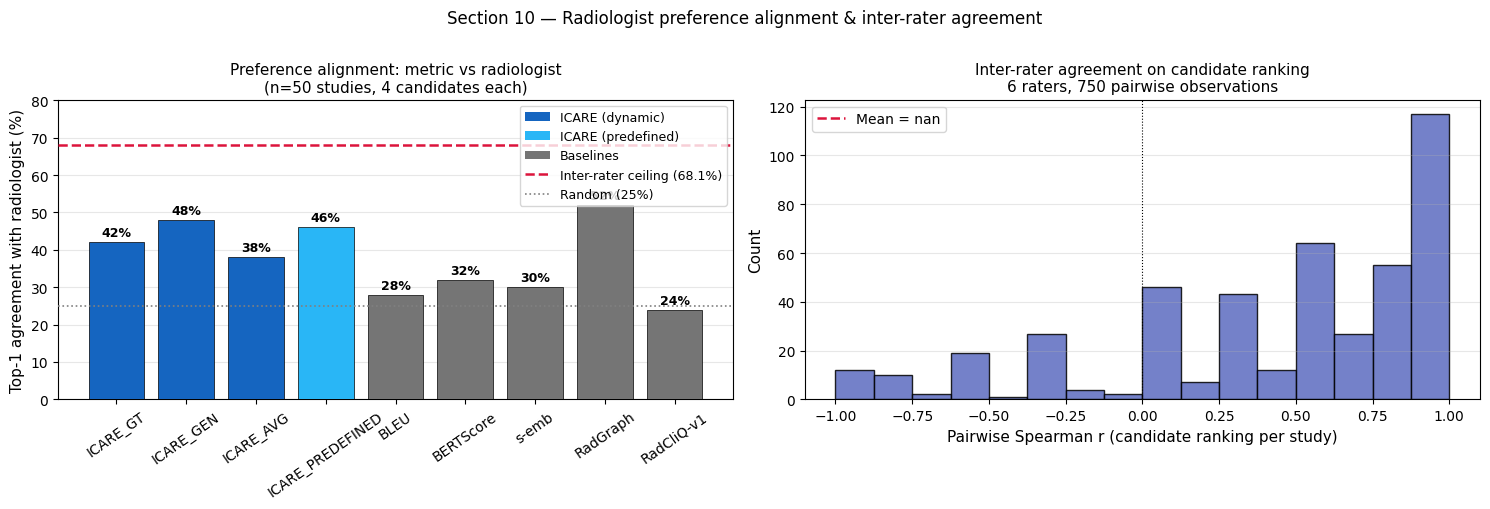

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# ── Left: preference alignment bar chart ──
labels  = list(pref_results.keys())
values  = list(pref_results.values())

# Colour: ICARE dynamic = blue, predefined = cyan, baselines = grey
colors = ['#1565C0', '#1565C0', '#1565C0',   # ICARE_GT/GEN/AVG
          '#29B6F6',                           # ICARE_PREDEFINED
          '#757575', '#757575', '#757575', '#757575', '#757575']  # baselines

bars = axes[0].bar(labels, values, color=colors, edgecolor='k', linewidth=0.5, zorder=3)
axes[0].axhline(inter_rater_top1, color='crimson', linestyle='--', linewidth=1.8,
                label=f'Inter-rater ceiling ({inter_rater_top1:.1f}%)', zorder=4)
axes[0].axhline(25, color='gray', linestyle=':', linewidth=1.2,
                label='Random (25%)', zorder=4)
axes[0].set_ylabel('Top-1 agreement with radiologist (%)', fontsize=11)
axes[0].set_title('Preference alignment: metric vs radiologist\n(n=50 studies, 4 candidates each)', fontsize=11)
axes[0].set_ylim(0, max(values + [inter_rater_top1]) + 12)
axes[0].tick_params(axis='x', rotation=35)
axes[0].legend(fontsize=10)
axes[0].grid(axis='y', alpha=0.3, zorder=0)
for bar, val in zip(bars, values):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.8,
                 f'{val:.0f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

# Legend patches
from matplotlib.patches import Patch
legend_patches = [
    Patch(facecolor='#1565C0', label='ICARE (dynamic)'),
    Patch(facecolor='#29B6F6', label='ICARE (predefined)'),
    Patch(facecolor='#757575', label='Baselines'),
]
axes[0].legend(handles=legend_patches + [
    plt.Line2D([0], [0], color='crimson', linestyle='--', linewidth=1.8,
               label=f'Inter-rater ceiling ({inter_rater_top1:.1f}%)'),
    plt.Line2D([0], [0], color='gray', linestyle=':', linewidth=1.2, label='Random (25%)'),
], fontsize=9, loc='upper right')

# ── Right: inter-rater Spearman r distribution ──
axes[1].hist(pairs_r, bins=16, edgecolor='k', color='#5C6BC0', alpha=0.85)
axes[1].axvline(inter_rater_spearman, color='crimson', linestyle='--', linewidth=1.8,
                label=f'Mean = {inter_rater_spearman:.3f}')
axes[1].axvline(0, color='k', linestyle=':', linewidth=0.8)
axes[1].set_xlabel('Pairwise Spearman r (candidate ranking per study)', fontsize=11)
axes[1].set_ylabel('Count', fontsize=11)
axes[1].set_title(f'Inter-rater agreement on candidate ranking\n'
                  f'6 raters, {len(pairs_r)} pairwise observations', fontsize=11)
axes[1].legend(fontsize=10)
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Section 10 — Radiologist preference alignment & inter-rater agreement', y=1.01, fontsize=12)
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/preference_alignment_all_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. Forest plot — preference alignment on decisive-consensus studies

Only studies where the majority of radiologists clearly agree on the best candidate are kept.  
Two thresholds are tried; the one with the larger n is used for the figure.

- **≥4-of-6 raters** agree on top-1 (strict majority, analogous to ≥2-of-3 in the reference paper)  
- **≥3-of-6 raters** agree on top-1 (plurality — more permissive, larger n)

Chance level = **25%** (4 candidates).  
95% CI via 1000-iteration bootstrap.

In [22]:
def build_decisive_consensus(rater_top1_df, threshold):
    """
    For each study find the consensus_winner (candidate most raters ranked #1)
    and keep only studies where ≥ threshold raters agree.
    Returns (decisive_df with columns [study_number, consensus_winner], n).
    """
    # Count how many raters picked each candidate as #1 per study
    vote_counts = (
        rater_top1_df
        .groupby(['study_number', 'origin'])
        .size()
        .reset_index(name='votes')
    )
    # Winner per study = candidate with the most votes
    idx = vote_counts.groupby('study_number')['votes'].idxmax()
    winners = vote_counts.loc[idx, ['study_number', 'origin', 'votes']].reset_index(drop=True)
    winners = winners.rename(columns={'origin': 'consensus_winner'})
    decisive = winners[winners['votes'] >= threshold].reset_index(drop=True)
    return decisive[['study_number', 'consensus_winner']], len(decisive)


def alignment_with_ci(decisive_df, metric_top1_df, n_boot=1000, seed=42):
    """
    % of decisive studies where metric top-1 == consensus_winner + 95% CI.
    metric_top1_df: columns [study_number, metric_winner].
    """
    df = decisive_df.merge(metric_top1_df, on='study_number')
    hits = (df['consensus_winner'] == df['metric_winner']).values.astype(float)
    pct = hits.mean() * 100
    rng = np.random.default_rng(seed)
    n = len(hits)
    boot = [rng.choice(hits, n, replace=True).mean() * 100 for _ in range(n_boot)]
    lo, hi = np.percentile(boot, 2.5), np.percentile(boot, 97.5)
    return pct, lo, hi, n


# ── Build rater top-1 DataFrame (reuse from Section 10) ──
# rater_top1 was computed in cell-30 (inter-rater agreement cell)

# Try both thresholds
for thr in [4, 3]:
    decisive_tmp, n_tmp = build_decisive_consensus(rater_top1, thr)
    print(f'Threshold ≥{thr}/6 : n = {n_tmp} decisive studies  '
          f'({n_tmp/50*100:.0f}% of 50 studies)')

# Pick the threshold with more decisive studies (≥3 will always be ≥ ≥4)
# Show both ns, then use the larger-n threshold for the plot
decisive_4, n4 = build_decisive_consensus(rater_top1, 4)
decisive_3, n3 = build_decisive_consensus(rater_top1, 3)
THRESHOLD, decisive_df, N_DECISIVE = (4, decisive_4, n4) if n4 >= 25 else (3, decisive_3, n3)
print(f'\n→ Using threshold ≥{THRESHOLD}/6  (n={N_DECISIVE})')

Threshold ≥4/6 : n = 38 decisive studies  (76% of 50 studies)
Threshold ≥3/6 : n = 49 decisive studies  (98% of 50 studies)

→ Using threshold ≥4/6  (n=38)


In [ ]:
# Compute alignment + CI for every metric on the decisive-consensus subset
FOREST_METRICS = [
    ('ICARE_AVG ◄',      'ICARE_DIS_AVG',          True),
    ('ICARE_GT',         'ICARE_DIS_GT',            True),
    ('ICARE_GEN',        'ICARE_DIS_GEN',           True),
    ('ICARE_PREDEFINED', 'ICARE_DIS_PREDEFINED',    True),
    ('BLEU',             'neg_bleu_score',          True),
    ('BERTScore',        'neg_bertscore',           True),
    ('s-emb',            'neg_semb_score',          True),
    ('RadGraph',         'neg_radgraph_combined',   True),
    ('RadCliQ-v1',       'RadCliQ-v1',          True),
    ('GREEN',            'neg_green_score',     True),
    ('CRIMSON',          'neg_crimson_score',   True),
]

forest_data = []
for label, col, asc in FOREST_METRICS:
    metric_top1 = (
        merged_all
        .assign(_r=merged_all.groupby('study_number')[col].rank(ascending=asc, method='min'))
        .query('_r == 1')[['study_number', 'origin']]
        .drop_duplicates('study_number')
        .rename(columns={'origin': 'metric_winner'})
    )
    pct, lo, hi, n = alignment_with_ci(decisive_df, metric_top1)
    forest_data.append(dict(label=label, pct=pct, lo=lo, hi=hi))
    print(f'{label:22s}: {pct:.1f}%  [{lo:.1f}, {hi:.1f}]  (n={n})')

print(f'\nChance level: 25.0%  (4 candidates, uniform random)')

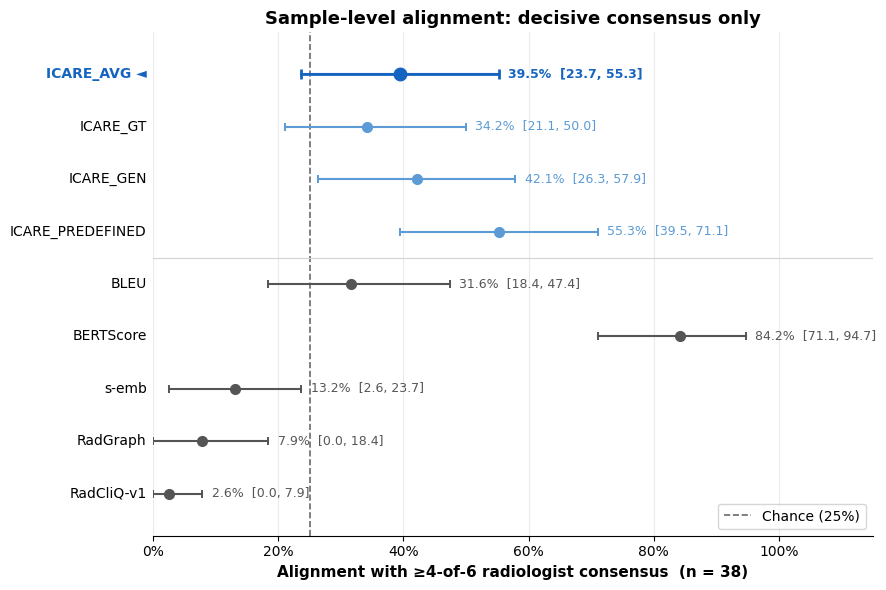

In [24]:
fig, ax = plt.subplots(figsize=(9, 6))

n_metrics = len(forest_data)
y_pos = np.arange(n_metrics)[::-1]   # top row = index 0

for i, (row, y) in enumerate(zip(forest_data, y_pos)):
    is_icare_avg = row['label'] == 'ICARE_AVG ◄'
    is_icare     = row['label'].startswith('ICARE')
    color     = '#1565C0' if is_icare_avg else ('#5C9BD6' if is_icare else '#555555')
    lw        = 2.0 if is_icare_avg else 1.4
    ms        = 9   if is_icare_avg else 7
    fontw     = 'bold' if is_icare_avg else 'normal'
    label_col = '#1565C0' if is_icare_avg else 'black'

    # Error bar (CI)
    ax.plot([row['lo'], row['hi']], [y, y], color=color, lw=lw, solid_capstyle='round', zorder=3)
    # Tick marks at CI ends
    ax.plot([row['lo'], row['hi']], [y, y], color=color, marker='|', ms=ms*0.8, mew=lw, zorder=3)
    # Central dot
    ax.plot(row['pct'], y, 'o', color=color, ms=ms, zorder=4)

    # Label on left
    ax.text(-1, y, row['label'], ha='right', va='center', fontsize=10,
            color=label_col, fontweight=fontw)
    # Value on right
    ax.text(max(row['hi'], row['pct']) + 1.5, y,
            f"{row['pct']:.1f}%  [{row['lo']:.1f}, {row['hi']:.1f}]",
            ha='left', va='center', fontsize=9, color=color, fontweight=fontw)

# Reference lines
ax.axvline(25, color='dimgray', linestyle='--', linewidth=1.2, zorder=2, label='Chance (25%)')

# Separator between ICARE and baselines (after ICARE_PREDEFINED, 4th row from top)
n_icare = sum(1 for r in forest_data if r['label'].startswith('ICARE'))
sep_y = y_pos[n_icare - 1] - 0.5
ax.axhline(sep_y, color='lightgray', linewidth=0.8, linestyle='-')

ax.set_xlim(0, 115)
ax.set_ylim(-0.8, n_metrics - 0.2)
ax.set_xlabel(f'Alignment with ≥{THRESHOLD}-of-6 radiologist consensus  (n = {N_DECISIVE})',
              fontsize=11, fontweight='bold')
ax.set_title('Sample-level alignment: decisive consensus only', fontsize=13, fontweight='bold')
ax.set_yticks([])
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0f}%'))
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.legend(fontsize=10, loc='lower right')
ax.grid(axis='x', alpha=0.25, zorder=0)

plt.tight_layout()
plt.savefig(f'{OUT_DIR}/forest_plot_decisive_consensus.png', dpi=150, bbox_inches='tight')
plt.show()

## 12. Per-rater analysis

Two figures inspired by the CRIMSON-style plot:

1. **Per-rater Kendall τ and Pearson r** — correlate each metric against each individual rater's error counts; show all 6 rater dots + averaged; inter-rater in a right panel  
2. **Per-rater preference alignment** — forest-plot style alignment % with each individual rater's top-1 pick; mean + 95 % CI as the main dot; individual raters as jittered dots

In [ ]:
# ── Per-rater error counts per (study, candidate) ──
per_rater_errors = (
    clin_sig
    .groupby(['study_number', 'candidate_type', 'rater_index'])['num_errors']
    .sum()
    .reset_index()
    .rename(columns={'candidate_type': 'origin'})
)

RATERS = sorted(per_rater_errors['rater_index'].unique())
print(f'{len(RATERS)} raters: {RATERS}')

# Metrics and their score columns in merged_all
ALL_METRICS = [
    ('ICARE_GT',         'ICARE_DIS_GT'),
    ('ICARE_GEN',        'ICARE_DIS_GEN'),
    ('ICARE_AVG',        'ICARE_DIS_AVG'),
    ('ICARE_PRE',        'ICARE_DIS_PREDEFINED'),
    ('BLEU',             'neg_bleu_score'),
    ('BERTScore',        'neg_bertscore'),
    ('s-emb',            'neg_semb_score'),
    ('RadGraph',         'neg_radgraph_combined'),
    ('RadCliQ-v1',       'RadCliQ-v1'),
    ('GREEN',            'neg_green_score'),
    ('CRIMSON',          'neg_crimson_score'),
]

# For each metric × rater: Kendall τ and Pearson r
rater_corr = {}   # {metric_label: {rater: {tau, r}}}
for label, col in ALL_METRICS:
    rater_corr[label] = {}
    for rater in RATERS:
        rater_err = per_rater_errors[per_rater_errors['rater_index'] == rater][
            ['study_number', 'origin', 'num_errors']
        ]
        sub = merged_all.merge(rater_err, on=['study_number', 'origin'], how='inner')
        x = sub[col].values
        y = sub['num_errors'].values
        tau, _ = stats.kendalltau(x, y)
        r, _   = stats.pearsonr(x, y)
        rater_corr[label][rater] = dict(tau=tau, r=r)

# Inter-rater: Kendall τ and Pearson r between all rater pairs
inter_pairs = {'tau': [], 'r': []}
for r1, r2 in combinations(RATERS, 2):
    e1 = per_rater_errors[per_rater_errors['rater_index'] == r1].set_index(['study_number','origin'])['num_errors']
    e2 = per_rater_errors[per_rater_errors['rater_index'] == r2].set_index(['study_number','origin'])['num_errors']
    common = e1.index.intersection(e2.index)
    if len(common) >= 2:
        tau, _ = stats.kendalltau(e1[common].values, e2[common].values)
        r, _   = stats.pearsonr(e1[common].values, e2[common].values)
        inter_pairs['tau'].append(tau)
        inter_pairs['r'].append(r)

print(f'Inter-rater mean Kendall τ : {np.mean(inter_pairs["tau"]):.3f}')
print(f'Inter-rater mean Pearson r : {np.mean(inter_pairs["r"]):.3f}')
print('Per-metric averaged correlations:')
for label, _ in ALL_METRICS:
    avg_tau = np.mean([rater_corr[label][r]['tau'] for r in RATERS])
    avg_r   = np.mean([rater_corr[label][r]['r']   for r in RATERS])
    print(f'  {label:14s}  τ={avg_tau:.3f}  r={avg_r:.3f}')

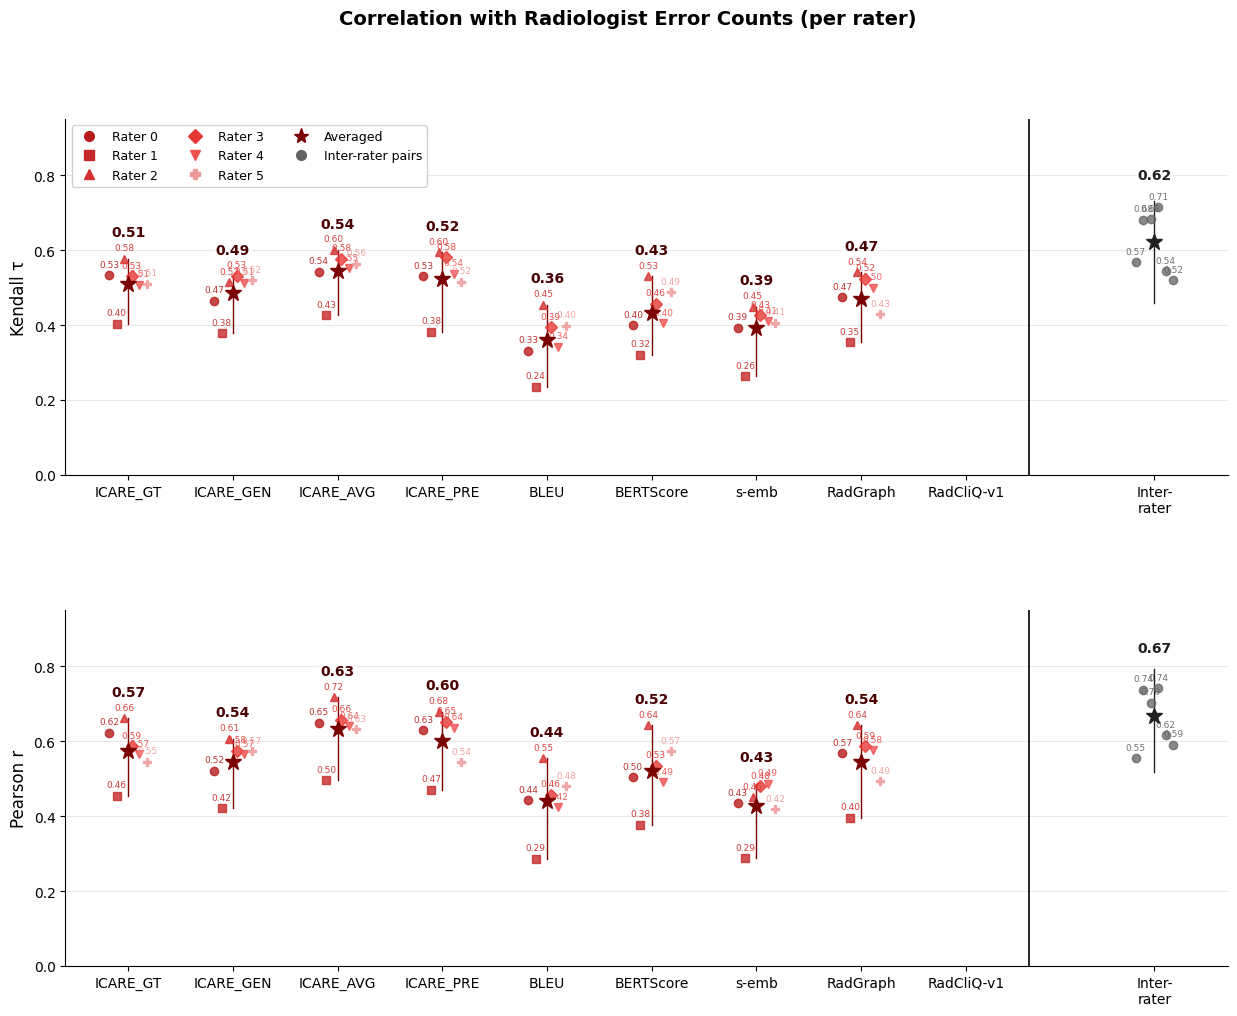

In [26]:
METRIC_LABELS = [m[0] for m in ALL_METRICS]
RATER_MARKERS  = ["o", "s", "^", "D", "v", "P"]
RATER_COLORS   = ["#B71C1C","#C62828","#D32F2F","#E53935","#EF5350","#EF9A9A"]

fig, axes = plt.subplots(2, 1, figsize=(15, 11), sharex=False)
fig.subplots_adjust(hspace=0.38)

for ax_idx, stat_key, ylabel in [(0, "tau", "Kendall τ"), (1, "r", "Pearson r")]:
    ax = axes[ax_idx]

    n_metrics = len(METRIC_LABELS)
    x_metrics = np.arange(n_metrics)
    x_inter   = n_metrics + 0.8

    jitter = np.linspace(-0.18, 0.18, len(RATERS))

    for m_i, label in enumerate(METRIC_LABELS):
        vals = [rater_corr[label][r][stat_key] for r in RATERS]
        avg  = np.mean(vals)

        for r_i, (rater, val) in enumerate(zip(RATERS, vals)):
            ax.plot(m_i + jitter[r_i], val,
                    marker=RATER_MARKERS[r_i], color=RATER_COLORS[r_i],
                    ms=6, alpha=0.80, zorder=3,
                    label=f"Rater {rater}" if m_i == 0 else "")
            ax.annotate(f"{val:.2f}", (m_i + jitter[r_i], val),
                        textcoords="offset points", xytext=(0, 6),
                        ha="center", fontsize=6.5, color=RATER_COLORS[r_i], alpha=0.9)

        ax.plot([m_i, m_i], [min(vals), max(vals)], color="#7B0000", lw=1.0, zorder=2)
        ax.plot(m_i, avg, "*", color="#7B0000", ms=12, zorder=5,
                label="Averaged" if m_i == 0 else "")
        # Bold averaged score above the group (placed just above max val or 0.8 whichever is lower)
        text_y = min(max(vals), 0.78)
        ax.annotate(f"{avg:.2f}", (m_i, text_y),
                    textcoords="offset points", xytext=(0, 16),
                    ha="center", fontsize=10, fontweight="bold", color="#4A0000",
                    bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.7))

    ax.axvline(n_metrics - 0.4, color="black", lw=1.2, ls="-")
    inter_vals = inter_pairs[stat_key]
    for r_i, val in enumerate(inter_vals[:len(RATERS)]):
        ax.plot(x_inter + jitter[r_i], val,
                marker="o", color="#616161", ms=6, alpha=0.75, zorder=3)
        ax.annotate(f"{val:.2f}", (x_inter + jitter[r_i], val),
                    textcoords="offset points", xytext=(0, 6),
                    ha="center", fontsize=6.5, color="#616161", alpha=0.9)

    inter_avg = np.mean(inter_vals)
    ax.plot([x_inter, x_inter], [min(inter_vals), max(inter_vals)],
            color="#212121", lw=1.0, zorder=2)
    ax.plot(x_inter, inter_avg, "*", color="#212121", ms=12, zorder=5)
    text_y_inter = min(max(inter_vals), 0.78)
    ax.annotate(f"{inter_avg:.2f}", (x_inter, text_y_inter),
                textcoords="offset points", xytext=(0, 16),
                ha="center", fontsize=10, fontweight="bold", color="#212121",
                bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.7))

    x_ticks  = list(x_metrics) + [x_inter]
    x_labels = METRIC_LABELS + ["Inter-\nrater"]
    ax.set_xticks(x_ticks)
    ax.set_xticklabels(x_labels, fontsize=10)
    ax.set_xlim(-0.6, x_inter + 0.7)
    ax.set_ylim(0, 0.95)
    ax.set_yticks([0, 0.2, 0.4, 0.6, 0.8])
    ax.set_ylabel(ylabel, fontsize=12)
    ax.yaxis.grid(True, alpha=0.3)
    ax.spines[["top", "right"]].set_visible(False)

    if ax_idx == 0:
        handles = ([plt.Line2D([0],[0], marker=RATER_MARKERS[i], color=RATER_COLORS[i],
                                ms=7, ls="", label=f"Rater {RATERS[i]}") for i in range(len(RATERS))]
                   + [plt.Line2D([0],[0], marker="*", color="#7B0000", ms=11, ls="", label="Averaged"),
                      plt.Line2D([0],[0], marker="o", color="#616161", ms=7, ls="", label="Inter-rater pairs")])
        ax.legend(handles=handles, fontsize=9, loc="upper left", ncol=3, framealpha=0.9)

fig.suptitle("Correlation with Radiologist Error Counts (per rater)", fontsize=14, fontweight="bold")
plt.savefig(f"{OUT_DIR}/per_rater_corr_crimson_style.png", dpi=150, bbox_inches="tight")
plt.show()

In [27]:
# Per-rater top-1 alignment % for every metric
# For each rater: % of studies where metric top-1 = that rater's top-1 pick
rater_top1_by_rater = {}
for rater in RATERS:
    rater_top1_by_rater[rater] = (
        rater_errors[rater_errors['rater_rank'] == 1]
        [rater_errors['rater_index'] == rater][['study_number', 'origin']]
        .drop_duplicates('study_number')
        .rename(columns={'origin': 'rater_winner'})
    )

forest_per_rater = []   # [{label, pcts:[6 values], mean, lo, hi}]
for label, col, asc in FOREST_METRICS:
    metric_top1 = (
        merged_all
        .assign(_r=merged_all.groupby('study_number')[col].rank(ascending=asc, method='min'))
        .query('_r == 1')[['study_number', 'origin']]
        .drop_duplicates('study_number')
        .rename(columns={'origin': 'metric_winner'})
    )
    per_rater_pcts = []
    for rater in RATERS:
        rt1 = rater_top1_by_rater[rater]
        df  = rt1.merge(metric_top1, on='study_number')
        per_rater_pcts.append((df['rater_winner'] == df['metric_winner']).mean() * 100)

    # Mean + 95 % CI across raters (bootstrap over raters as units)
    rng   = np.random.default_rng(42)
    arr   = np.array(per_rater_pcts)
    boots = [rng.choice(arr, len(arr), replace=True).mean() for _ in range(2000)]
    mean  = arr.mean()
    lo, hi = np.percentile(boots, 2.5), np.percentile(boots, 97.5)
    forest_per_rater.append(dict(label=label, pcts=per_rater_pcts, mean=mean, lo=lo, hi=hi))
    print(f'{label:22s}: {mean:.1f}%  [{lo:.1f}, {hi:.1f}]  raters={[round(p,1) for p in per_rater_pcts]}')

ICARE_AVG ◄           : 37.3%  [34.0, 40.3]  raters=[44.0, 36.0, 40.0, 34.0, 32.0, 38.0]
ICARE_GT              : 32.7%  [29.3, 36.0]  raters=[40.0, 32.0, 34.0, 32.0, 26.0, 32.0]
ICARE_GEN             : 36.3%  [34.0, 39.0]  raters=[42.0, 34.0, 36.0, 32.0, 38.0, 36.0]
ICARE_PREDEFINED      : 52.3%  [49.7, 56.0]  raters=[50.0, 48.0, 50.0, 60.0, 52.0, 54.0]
BLEU                  : 29.3%  [27.3, 31.7]  raters=[34.0, 32.0, 28.0, 30.0, 26.0, 26.0]
BERTScore             : 68.7%  [65.0, 73.0]  raters=[68.0, 78.0, 72.0, 64.0, 64.0, 66.0]
s-emb                 : 16.7%  [14.0, 20.0]  raters=[14.0, 12.0, 16.0, 18.0, 16.0, 24.0]
RadGraph              : 12.7%  [10.3, 14.7]  raters=[14.0, 8.0, 12.0, 16.0, 14.0, 12.0]
RadCliQ-v1            : 7.7%  [5.0, 10.3]  raters=[12.0, 10.0, 10.0, 4.0, 8.0, 2.0]


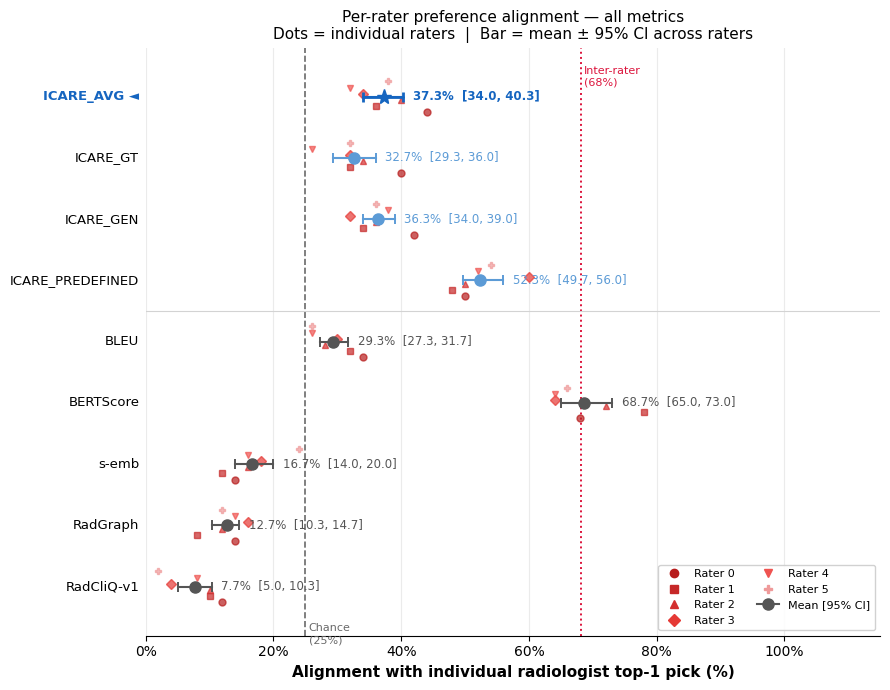

In [28]:
fig, ax = plt.subplots(figsize=(9, 7))

n_metrics = len(forest_per_rater)
y_pos = np.arange(n_metrics)[::-1]
jitter_y = np.linspace(-0.25, 0.25, len(RATERS))

for i, (row, y) in enumerate(zip(forest_per_rater, y_pos)):
    is_icare_avg = row['label'] == 'ICARE_AVG ◄'
    is_icare     = row['label'].startswith('ICARE')
    main_color   = '#1565C0' if is_icare_avg else ('#5C9BD6' if is_icare else '#555555')
    fontw        = 'bold' if is_icare_avg else 'normal'
    lw           = 2.0 if is_icare_avg else 1.4

    # Individual rater dots (small, jittered vertically)
    for r_i, pct in enumerate(row['pcts']):
        ax.plot(pct, y + jitter_y[r_i],
                marker=RATER_MARKERS[r_i], color=RATER_COLORS[r_i],
                ms=5, alpha=0.7, zorder=3)

    # Mean CI bar
    ax.plot([row['lo'], row['hi']], [y, y], color=main_color, lw=lw,
            solid_capstyle='round', zorder=4)
    ax.plot([row['lo'], row['hi']], [y, y], color=main_color,
            marker='|', ms=7, mew=lw, zorder=4)
    # Mean dot (star for ICARE_AVG, circle otherwise)
    marker = '*' if is_icare_avg else 'o'
    ms     = 11 if is_icare_avg else 8
    ax.plot(row['mean'], y, marker=marker, color=main_color, ms=ms, zorder=5)

    # Label (left) and value (right)
    ax.text(-1, y, row['label'], ha='right', va='center', fontsize=9.5,
            color=main_color if is_icare_avg else 'black', fontweight=fontw)
    ax.text(max(row['hi'], row['mean']) + 1.5, y,
            f"{row['mean']:.1f}%  [{row['lo']:.1f}, {row['hi']:.1f}]",
            ha='left', va='center', fontsize=8.5, color=main_color, fontweight=fontw)

# Reference lines
ax.axvline(25, color='dimgray', linestyle='--', linewidth=1.2, zorder=2)
ax.text(25.5, -0.6, 'Chance\n(25%)', va='top', fontsize=8, color='dimgray')
ax.axvline(inter_rater_top1, color='crimson', linestyle=':', linewidth=1.4, zorder=2)
ax.text(inter_rater_top1 + 0.5, n_metrics - 0.5,
        f'Inter-rater\n({inter_rater_top1:.0f}%)', va='top', fontsize=8, color='crimson')

# Separator between ICARE and baselines
n_icare = sum(1 for r in forest_per_rater if r['label'].startswith('ICARE'))
sep_y = y_pos[n_icare - 1] - 0.5
ax.axhline(sep_y, color='lightgray', linewidth=0.8)

# Legend: rater markers
rater_handles = [
    plt.Line2D([0],[0], marker=RATER_MARKERS[i], color=RATER_COLORS[i],
               ms=6, ls='', label=f'Rater {RATERS[i]}')
    for i in range(len(RATERS))
]
rater_handles += [plt.Line2D([0],[0], marker='o', color='#555555', ms=8,
                              ls='-', lw=1.5, label='Mean [95% CI]')]
ax.legend(handles=rater_handles, fontsize=8, loc='lower right', ncol=2, framealpha=0.9)

ax.set_xlim(0, 115)
ax.set_ylim(-0.8, n_metrics - 0.2)
ax.set_xlabel('Alignment with individual radiologist top-1 pick (%)', fontsize=11, fontweight='bold')
ax.set_title('Per-rater preference alignment — all metrics\n'
             'Dots = individual raters  |  Bar = mean ± 95% CI across raters', fontsize=11)
ax.set_yticks([])
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0f}%'))
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.grid(axis='x', alpha=0.25, zorder=0)

plt.tight_layout()
plt.savefig(f'{OUT_DIR}/forest_plot_per_rater.png', dpi=150, bbox_inches='tight')
plt.show()